In [ ]:
# =========================
# LHS ANALYSIS – unified pipeline
# =========================
import json, numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import statsmodels.api as sm

# ---------- CONFIG ----------
base = Path("/lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE")
p_params = base/"param_sets_50.json"
p_top    = base/"results_topology_param_sens_50.json"
p_chem   = base/"results_chemistry_param_sens_50.json"
outdir   = base/"analysis_outputs"
outdir.mkdir(exist_ok=True)

# Parameter columns (as they appear in your JSON)
param_cols = ["min_peaks", "max_comp_size", "max_links", "cut_off"]

# OPTIONAL: set metric directions/weights.
# If you leave these empty lists, the code will auto-detect metrics and apply a heuristic.
# Prefer explicitly listing what you want to MAX or MIN.
maximize_user = [
    # Topology
    "top_num_edges", "top_num_components", "top_num_nodes",
    # Chemistry
    "chem_net_avg_intra", "chem_net_avg_inter",
    "chem_edge_purity", "chem_edge_purity_adjusted",
    "chem_component_purity", "chem_component_purity_penalized",
    "chem_consistency_measurement", "chem_network_accuracy_score",
]
minimize_user = [
    "top_num_isolated_nodes",
    "top_n20_largest_clusters",
    # if you truly want to MINIMIZE a penalized metric, list it here instead of maximize
    # "chem_component_purity_penalized",
]


# Optional weights (match the final chosen metric lists; default=1.0 each)
weights = {}  # e.g., {"chem_network_accuracy_score": 2.0, "chem_consistency_measurement": 1.5}

# ---------- LOAD ----------
with open(p_params, "r") as f:
    param_sets = json.load(f)   # list[dict]
with open(p_top, "r") as f:
    top_dict = json.load(f)     # {score_name: list[dict]}
with open(p_chem, "r") as f:
    chem_dict = json.load(f)    # {score_name: list[dict]}

score_families = sorted(set(top_dict.keys()) & set(chem_dict.keys()))
param_df = pd.DataFrame(param_sets).assign(run=np.arange(len(param_sets)))

def make_df_for_score(score_name: str) -> pd.DataFrame:
    top_df  = pd.DataFrame(top_dict[score_name]).add_prefix("top_")
    chem_df = pd.DataFrame(chem_dict[score_name]).add_prefix("chem_")
    df = pd.concat([param_df, top_df, chem_df], axis=1)
    df["score_family"] = score_name
    return df

df_all = pd.concat([make_df_for_score(s) for s in score_families], ignore_index=True)

# ---------- DETECT METRICS ----------
all_cols = df_all.columns.tolist()
metric_cols_auto = [c for c in all_cols
                    if (c.startswith("top_") or c.startswith("chem_"))]

# Use user-provided lists if present; otherwise build a heuristic split
def split_metrics(maximize_hint, minimize_hint):
    if maximize_hint or minimize_hint:
        max_cols = [c for c in maximize_hint if c in metric_cols_auto]
        min_cols = [c for c in minimize_hint if c in metric_cols_auto]
        return max_cols, min_cols

    # Heuristic: maximize purities/accuracies/consistency/averages & num_edges/nodes/components,
    # minimize isolated nodes and N20-largest-clusters.
    max_like = ("purity", "accuracy", "consistency", "avg", "num_edges", "num_nodes", "num_components", "adjusted")
    min_like = ("isolated", "n20")

    max_cols, min_cols = [], []
    for c in metric_cols_auto:
        name = c.lower()
        if any(k in name for k in min_like):
            min_cols.append(c)
        elif any(k in name for k in max_like):
            max_cols.append(c)
        else:
            # default to maximize for unspecified positive metrics
            max_cols.append(c)
    return max_cols, min_cols

maximize, minimize = split_metrics(maximize_user, minimize_user)

# Remove anything non-numeric
for col in maximize + minimize:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# ---------- PER-FAMILY COMPOSITE SCORE ----------
df_all["composite_score"] = np.nan
for fam in df_all["score_family"].unique():
    sub = df_all[df_all.score_family == fam]
    # standardize per family
    Zmax = StandardScaler().fit_transform(sub[maximize]) if maximize else np.zeros((len(sub),0))
    Zmin = -StandardScaler().fit_transform(sub[minimize]) if minimize else np.zeros((len(sub),0))

    # weights
    w_max = np.array([weights.get(c, 1.0) for c in maximize]) if maximize else np.array([])
    w_min = np.array([weights.get(c, 1.0) for c in minimize]) if minimize else np.array([])

    score = (Zmax @ w_max if w_max.size else 0) + (Zmin @ w_min if w_min.size else 0)
    df_all.loc[sub.index, "composite_score"] = score

# ---------- PER-FAMILY PARETO FRONT ----------
def pareto_front(M):
    """M: higher is better on all columns"""
    n = M.shape[0]
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        dominates_i = np.all(M >= M[i], axis=1) & np.any(M > M[i], axis=1)
        dominates_i[i] = False
        if np.any(dominates_i):
            is_pareto[i] = False
    return is_pareto

df_all["is_pareto"] = False
for fam in df_all["score_family"].unique():
    sub = df_all[df_all.score_family == fam]
    objs = []
    if maximize: objs.append(StandardScaler().fit_transform(sub[maximize]))
    if minimize: objs.append(-StandardScaler().fit_transform(sub[minimize]))  # negate so higher=better
    if not objs: 
        continue
    OBJ = np.column_stack(objs)
    df_all.loc[sub.index, "is_pareto"] = pareto_front(OBJ)

# ---------- PER-FAMILY OLS SIGNIFICANCE ----------
ols_rows = []
for fam in df_all["score_family"].unique():
    sub = df_all[df_all.score_family == fam]
    X = sm.add_constant(sub[param_cols])
    for m in (maximize + minimize):
        y = sub[m]
        try:
            model = sm.OLS(y, X, missing='drop').fit()
            ols_rows.append(pd.DataFrame({
                "family": fam,
                "metric": m,
                "term": model.params.index,
                "coef": model.params.values,
                "pval": model.pvalues.values,
                "std_err": model.bse.values,
                "r2": model.rsquared
            }))
        except Exception:
            pass
ols_results = pd.concat(ols_rows, ignore_index=True)

# ---------- PER-FAMILY RF PERMUTATION IMPORTANCE ----------
rf_rows = []
for fam in df_all["score_family"].unique():
    sub = df_all[df_all.score_family == fam]
    X = sub[param_cols].values
    for m in (maximize + minimize):
        y = pd.to_numeric(sub[m], errors="coerce").values
        mask = ~np.isnan(y)
        Xm, ym = X[mask], y[mask]
        if len(np.unique(ym)) <= 1 or len(ym) < 5:
            # no variance or too few points → return zeros to keep shape
            rf_rows.append(pd.DataFrame({
                "family": fam, "metric": m,
                "param": param_cols, "perm_importance": np.zeros(len(param_cols))
            }))
            continue
        rf = RandomForestRegressor(n_estimators=400, random_state=0)
        rf.fit(Xm, ym)
        perm = permutation_importance(rf, Xm, ym, n_repeats=10, random_state=0)
        rf_rows.append(pd.DataFrame({
            "family": fam, "metric": m,
            "param": param_cols, "perm_importance": perm.importances_mean
        }))
rf_results = pd.concat(rf_rows, ignore_index=True)

# ---------- TOP COMBINATIONS & EXPORT ----------
best_overall = (df_all
    .sort_values(["score_family","composite_score"], ascending=[True, False])
    .groupby("score_family", as_index=False)
    .head(10))

pareto = df_all[df_all["is_pareto"]].sort_values(
    ["score_family","composite_score"], ascending=[True, False]
)

# Save
df_all.to_csv(outdir/"all_runs_merged.csv", index=False)
best_overall.to_csv(outdir/"top10_by_score_per_family.csv", index=False)
pareto.to_csv(outdir/"pareto_front.csv", index=False)
ols_results.to_csv(outdir/"ols_param_significance.csv", index=False)
rf_results.to_csv(outdir/"rf_param_importance.csv", index=False)

print("Saved:",
      outdir/"all_runs_merged.csv",
      outdir/"top10_by_score_per_family.csv",
      outdir/"pareto_front.csv",
      outdir/"ols_param_significance.csv",
      outdir/"rf_param_importance.csv",
      sep="\n - ")


/lustre/BIF/nobackup/charr003/miniforge3/envs/matchms/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/lustre/BIF/nobackup/charr003/miniforge3/envs/matchms/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/lustre/BIF/nobackup/charr003/miniforge3/envs/matchms/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Saved:
 - /lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE/analysis_outputs/all_runs_merged.csv
 - /lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE/analysis_outputs/top10_by_score_per_family.csv
 - /lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE/analysis_outputs/pareto_front.csv
 - /lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE/analysis_outputs/ols_param_significance.csv
 - /lustre/BIF/nobackup/charr003/projects/PostDoc/WP2_Rosina/Results_DoE/analysis_outputs/rf_param_importance.csv


Parameters: ['min_peaks', 'max_comp_size', 'max_links', 'cut_off']
Metrics: ['top_num_nodes', 'top_num_components', 'top_num_edges', 'top_num_isolated_nodes', 'top_n20_largest_clusters', 'chem_net_avg_intra', 'chem_net_avg_inter', 'chem_edge_purity', 'chem_component_purity', 'chem_edge_purity_adjusted', 'chem_component_purity_penalized', 'chem_consistency_measurement', 'chem_network_accuracy_score']


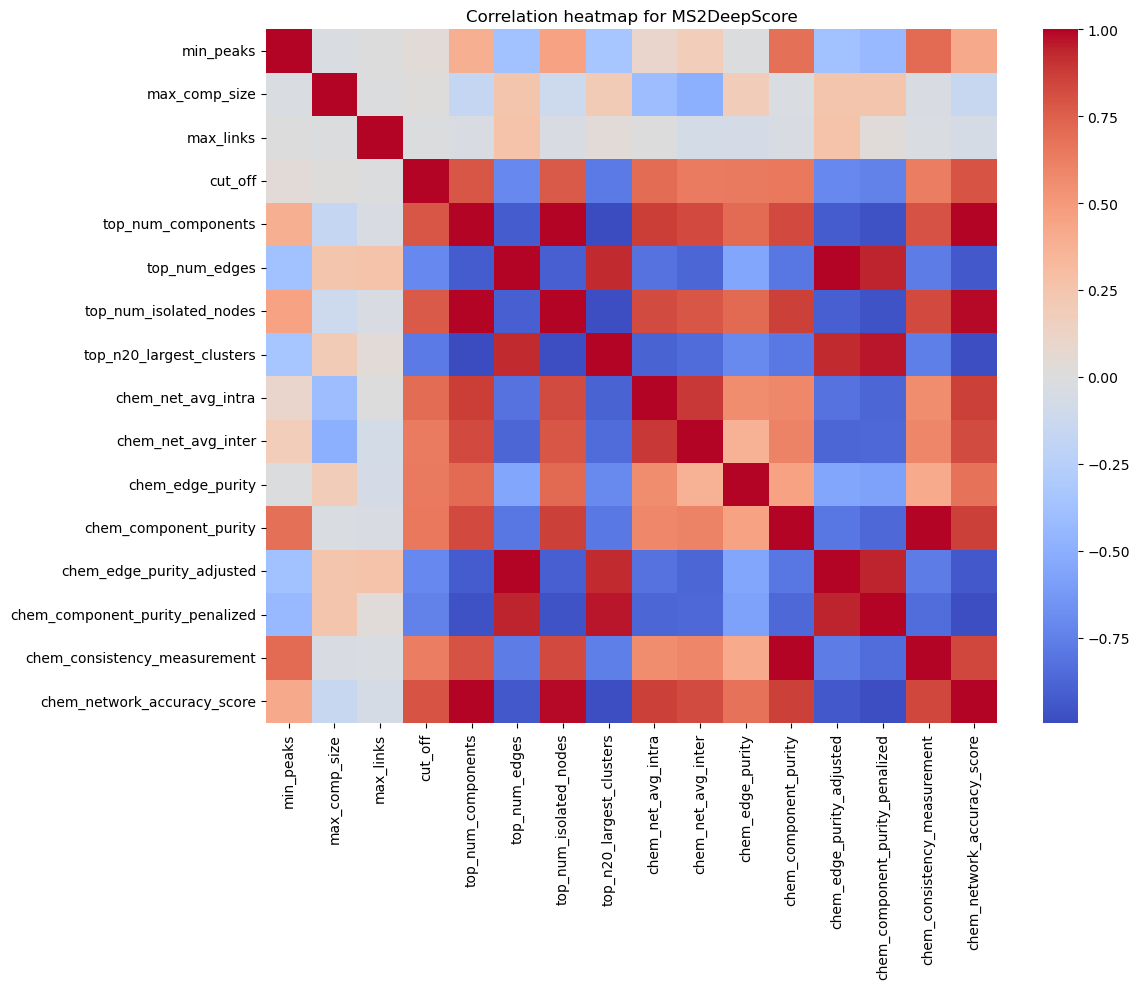

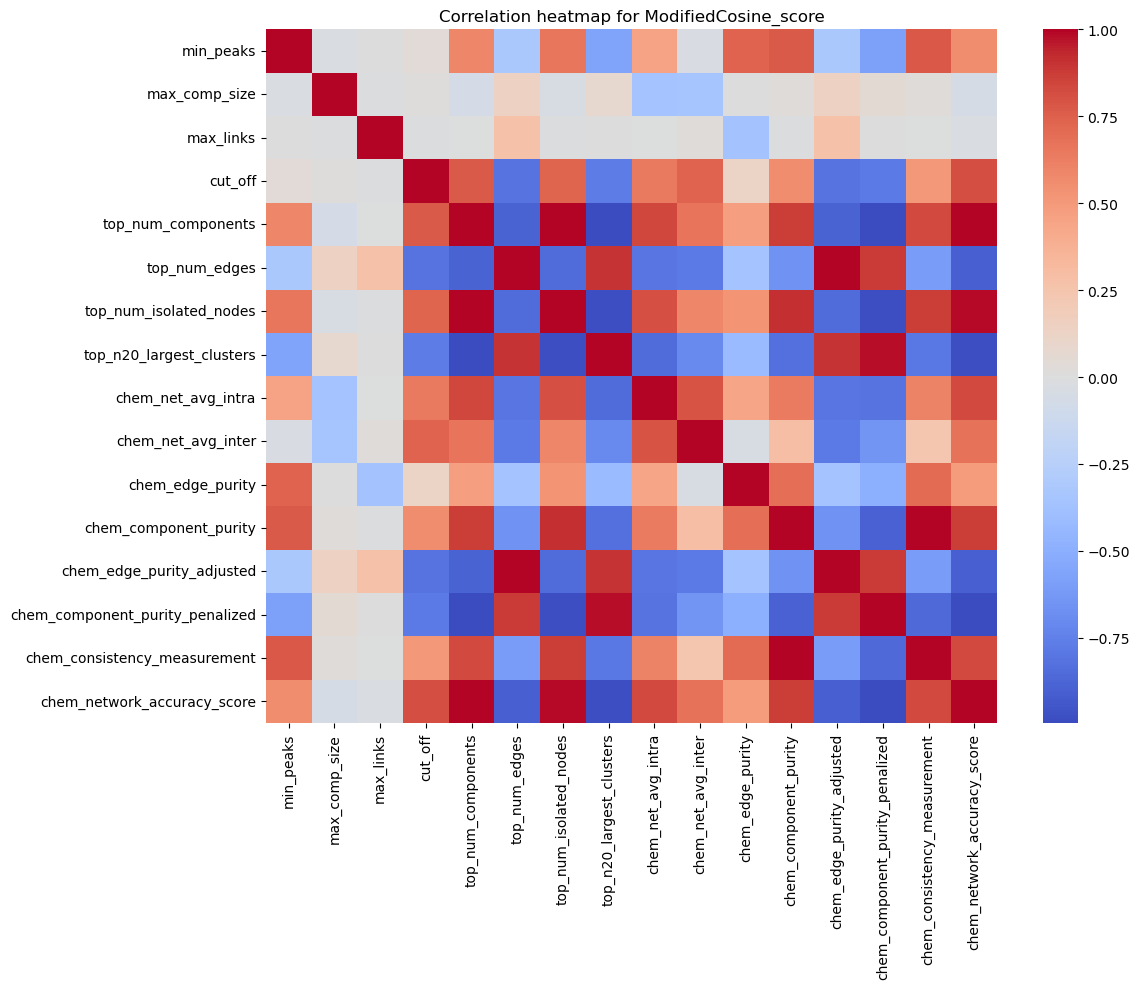

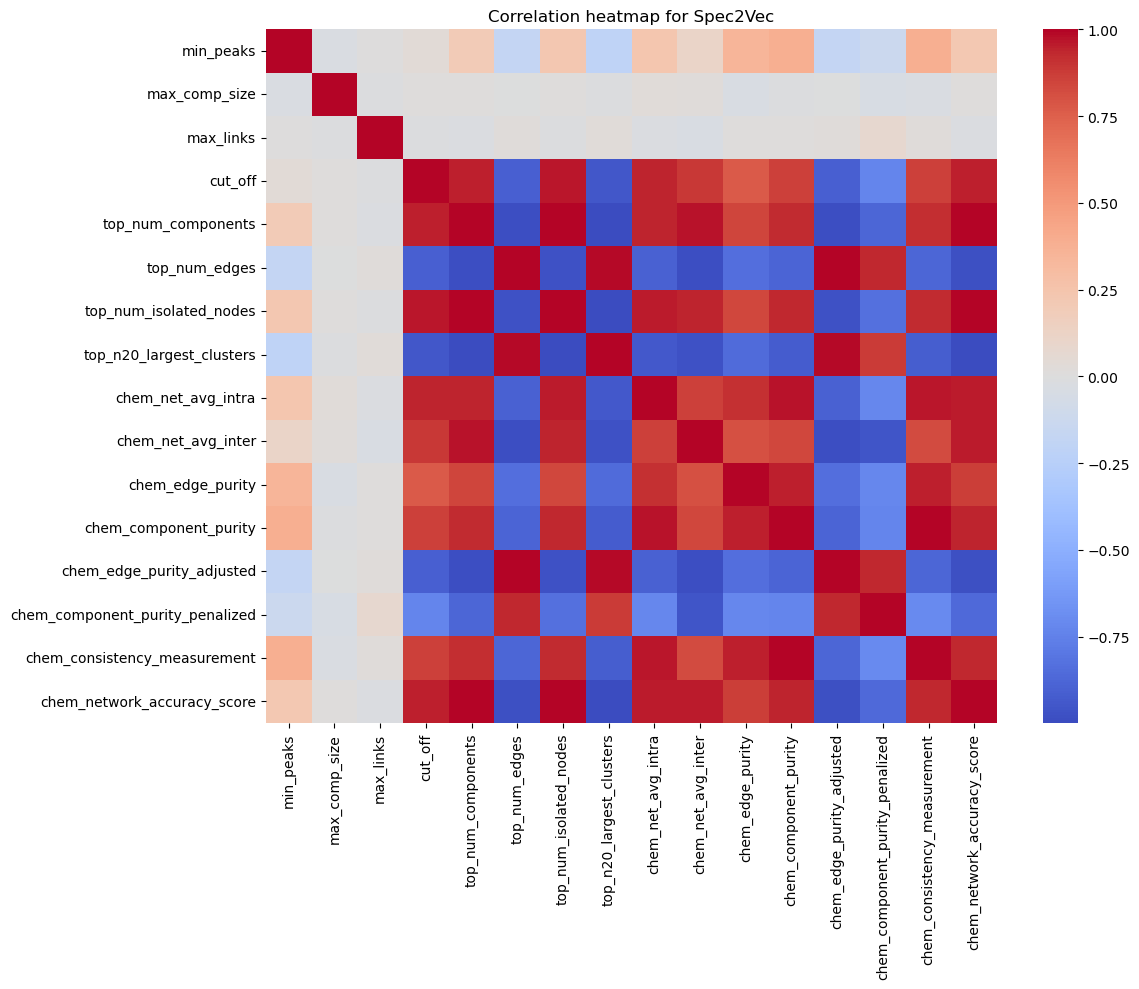

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

param_cols = ["min_peaks","max_comp_size","max_links","cut_off"]

# auto-detect metric columns
metric_cols = [c for c in df_all.columns
               if (c.startswith("top_") or c.startswith("chem_"))
               and c not in ["top_network_component_size_metric"]]

print("Parameters:", param_cols)
print("Metrics:", metric_cols)

# ---- correlation per score_family ----
for fam in df_all["score_family"].unique():
    sub = df_all[df_all["score_family"] == fam].copy()

    # build columns to plot (and keep only those that exist in sub)
    cols = [c for c in (param_cols + metric_cols) if c in sub.columns]

    # ensure numeric; drop all-NaN and zero-variance cols
    for c in cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
    nunique = sub[cols].nunique(dropna=True)
    cols_use = [c for c in cols if sub[c].notna().any() and nunique[c] > 1]

    if len(cols_use) < 2:
        print(f"[{fam}] Not enough varying numeric columns to plot.")
        continue

    corr = sub[cols_use].corr(numeric_only=True)

    plt.figure(figsize=(12,10))
    sns.heatmap(corr, center=0, cmap="coolwarm", annot=False,
                xticklabels=corr.columns, yticklabels=corr.index)
    plt.title(f"Correlation heatmap for {fam}")
    plt.tight_layout()
    plt.show()

